# Notebook 4 — FLAML AutoML vs Baseline Comparison

**Goal:** Run FLAML AutoML on the same Jan 2023 processed dataset and compare its best model against the 6 baselines from Notebook 3.

**Why FLAML?**
- Searches over XGBoost, LightGBM, Random Forest automatically
- Respects our pre-defined time-based train/val split
- Built-in MLflow logging
- Returns a standard sklearn-compatible model — drop-in replacement for `best_model.pkl`

**Split:** Same time-based split as Notebook 3 (last 7 days = test, prior 7 days = val).

**Outcome:** If FLAML beats the baseline val MAE (2.5457 min), it overwrites `models/best_model.pkl`.

---
## Section 1 — Imports & Configuration

In [1]:
import json
import logging
import pickle
import warnings
from datetime import timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from flaml import AutoML

import mlflow
import mlflow.sklearn

warnings.filterwarnings('ignore')
logging.getLogger('mlflow.sklearn').setLevel(logging.ERROR)
logging.getLogger('flaml').setLevel(logging.WARNING)
pd.set_option('display.float_format', '{:.4f}'.format)

print('All imports OK')
print(f'FLAML version: {__import__("flaml").__version__}')

/opt/anaconda3/envs/nyc-taxi-ml/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK
FLAML version: 2.6.0


In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
NOTEBOOK_DIR  = Path().resolve()
PROJECT_ROOT  = NOTEBOOK_DIR.parent
CONFIG_PATH   = PROJECT_ROOT / 'configs' / 'config.yaml'

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

YEAR  = cfg['data']['year']
MONTH = cfg['data']['month']

PROCESSED_PATH     = PROJECT_ROOT / cfg['data']['paths']['processed'].format(year=YEAR, month=MONTH)
MODELS_DIR         = PROJECT_ROOT / cfg['data']['paths']['models']
METADATA_SAVE_PATH = MODELS_DIR / 'model_metadata.json'
MODEL_SAVE_PATH    = MODELS_DIR / 'best_model.pkl'

# ── Training config ─────────────────────────────────────────────────────────
RANDOM_STATE         = cfg['training']['random_state']
VAL_DAYS             = cfg['training']['val_days']
TARGET               = cfg['features']['target']
NUMERIC_FEATURES     = cfg['features']['numeric']
CATEGORICAL_FEATURES = cfg['features']['categorical']

# ── FLAML budget ────────────────────────────────────────────────────────────
FLAML_TIME_BUDGET = 300   # seconds — increase for better results

# ── MLflow ──────────────────────────────────────────────────────────────────
MLFLOW_TRACKING_URI = f"sqlite:///{PROJECT_ROOT / cfg['mlflow']['tracking_uri']}"
EXPERIMENT_NAME     = cfg['mlflow']['experiment_name']

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print(f'Config loaded  : {CONFIG_PATH}')
print(f'Processed data : {PROCESSED_PATH}')
print(f'MLflow URI     : {MLFLOW_TRACKING_URI}')
print(f'FLAML budget   : {FLAML_TIME_BUDGET}s')

Config loaded  : /Users/adityaboghara/Desktop/NYC End to End Project /nyc-taxi-duration-prediction-self-healing-ml/configs/config.yaml
Processed data : /Users/adityaboghara/Desktop/NYC End to End Project /nyc-taxi-duration-prediction-self-healing-ml/data/processed/processed_rides_2023-01.parquet
MLflow URI     : sqlite:////Users/adityaboghara/Desktop/NYC End to End Project /nyc-taxi-duration-prediction-self-healing-ml/mlflow.db
FLAML budget   : 300s


---
## Section 2 — Load Processed Dataset

In [3]:
df = pd.read_parquet(PROCESSED_PATH)

if 'tpep_pickup_datetime' in df.columns:
    df = df.rename(columns={'tpep_pickup_datetime': 'pickup_datetime'})

available_features = [c for c in NUMERIC_FEATURES + CATEGORICAL_FEATURES if c in df.columns]


print(f'Shape      : {df.shape}')
print(f'Date range : {df["pickup_datetime"].min()}  →  {df["pickup_datetime"].max()}')
print(f'Features   : {available_features}')

Shape      : (2883614, 14)
Date range : 2023-01-01 00:00:05  →  2023-01-31 23:59:59
Features   : ['trip_distance', 'passenger_count', 'hour', 'dayofweek', 'PU_borough_id', 'DO_borough_id', 'PULocationID', 'DOLocationID', 'RatecodeID', 'is_weekend', 'is_rush_hour', 'is_airport_trip']


---
## Section 3 — Time-Based Train / Val / Test Split

Identical split to Notebook 3 so results are directly comparable.

In [4]:
df_sorted   = df.sort_values('pickup_datetime').reset_index(drop=True)
test_cutoff = df_sorted['pickup_datetime'].max() - timedelta(days=VAL_DAYS)
val_cutoff  = test_cutoff - timedelta(days=VAL_DAYS)

train_df = df_sorted[df_sorted['pickup_datetime'] <= val_cutoff]
val_df   = df_sorted[(df_sorted['pickup_datetime'] > val_cutoff) & (df_sorted['pickup_datetime'] <= test_cutoff)]
test_df  = df_sorted[df_sorted['pickup_datetime'] > test_cutoff]

X_train, y_train = train_df[available_features], train_df[TARGET]
X_val,   y_val   = val_df[available_features],   val_df[TARGET]
X_test,  y_test  = test_df[available_features],  test_df[TARGET]

print(f'Train : {len(X_train):,} rows  (Jan 1  – Jan 17)')
print(f'Val   : {len(X_val):,} rows  (Jan 18 – Jan 24)')
print(f'Test  : {len(X_test):,} rows  (Jan 25 – Jan 31)')

Train : 1,524,201 rows  (Jan 1  – Jan 17)
Val   : 683,024 rows  (Jan 18 – Jan 24)
Test  : 676,389 rows  (Jan 25 – Jan 31)


---
## Section 4 — Load Baseline Results

Pull the baseline metrics from `model_metadata.json` saved by Notebook 3.

In [5]:
with open(METADATA_SAVE_PATH) as f:
    baseline_meta = json.load(f)

BASELINE_MODEL   = baseline_meta['model_name']
BASELINE_VAL_MAE = baseline_meta['val_metrics']['mae']

print(f'Baseline model   : {BASELINE_MODEL}')
print(f'Baseline val MAE : {BASELINE_VAL_MAE:.4f} min')
print(f'Baseline val RMSE: {baseline_meta["val_metrics"]["rmse"]:.4f} min')
print(f'Baseline val R²  : {baseline_meta["val_metrics"]["r2"]:.4f}')

print('\n=== All baseline models (val MAE) ===')
all_val = baseline_meta['all_val_results']
for name, m in sorted(all_val.items(), key=lambda x: x[1]['mae']):
    print(f'  {name:<25}  MAE={m["mae"]:.4f}  RMSE={m["rmse"]:.4f}  R²={m["r2"]:.4f}')

Baseline model   : xgboost_raw
Baseline val MAE : 2.5457 min
Baseline val RMSE: 4.0552 min
Baseline val R²  : 0.8601

=== All baseline models (val MAE) ===
  xgboost_raw                MAE=2.5457  RMSE=4.0552  R²=0.8601
  xgboost_log                MAE=2.5512  RMSE=4.1605  R²=0.8528
  lightgbm                   MAE=2.6596  RMSE=4.1946  R²=0.8504
  random_forest              MAE=2.8822  RMSE=4.5243  R²=0.8259
  linear_regression          MAE=4.1761  RMSE=6.0435  R²=0.6894
  dummy_mean                 MAE=7.6877  RMSE=10.8435  R²=-0.0000


---
## Section 5 — FLAML AutoML

FLAML searches over XGBoost, LightGBM, and Random Forest using our pre-defined validation set.

- `time_budget` — total wall-clock seconds for the search
- `metric='mae'` — matches our primary evaluation metric
- `eval_method='holdout'` + `X_val/y_val` — uses our time-based val set instead of cross-validation

In [6]:
automl = AutoML()

automl_settings = {
    'task'            : 'regression',
    'metric'          : 'mae',
    'time_budget'     : FLAML_TIME_BUDGET,
    'estimator_list'  : ['xgboost', 'lgbm', 'rf'],
    'eval_method'     : 'holdout',
    'X_val'           : X_val,
    'y_val'           : y_val,
    'seed'            : RANDOM_STATE,
    'verbose'         : 1,
}

print(f'Starting FLAML search — budget: {FLAML_TIME_BUDGET}s ...')
automl.fit(X_train, y_train, **automl_settings)
print('\nFLAML search complete.')

Starting FLAML search — budget: 300s ...

FLAML search complete.


In [7]:
print(f'Best estimator : {automl.best_estimator}')
print(f'Best val MAE   : {automl.best_loss:.4f} min')
print(f'\nBest hyperparams:')
for k, v in automl.best_config.items():
    print(f'  {k}: {v}')

Best estimator : xgboost
Best val MAE   : 2.4651 min

Best hyperparams:
  n_estimators: 4006
  max_leaves: 34
  min_child_weight: 1.7851531187531517
  learning_rate: 0.2515117524630534
  subsample: 0.7299467041601126
  colsample_bylevel: 0.9269566304336126
  colsample_bytree: 1.0
  reg_alpha: 0.0011621666401916402
  reg_lambda: 4.639563015082658


---
## Section 6 — Evaluate FLAML Model

In [8]:
def evaluate(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    if label:
        print(f'{label:<40}  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}')
    return {'mae': mae, 'rmse': rmse, 'r2': r2}

flaml_val_pred  = automl.predict(X_val)
flaml_test_pred = automl.predict(X_test)

flaml_val_metrics  = evaluate(y_val,  flaml_val_pred,  'FLAML AutoML (val)')
flaml_test_metrics = evaluate(y_test, flaml_test_pred, 'FLAML AutoML (test)')

FLAML AutoML (val)                        MAE=2.4651  RMSE=3.9683  R²=0.8661
FLAML AutoML (test)                       MAE=2.5740  RMSE=4.2092  R²=0.8467


In [9]:
with mlflow.start_run(run_name='flaml_automl'):
    mlflow.log_param('best_estimator', automl.best_estimator)
    mlflow.log_param('time_budget_s',  FLAML_TIME_BUDGET)
    mlflow.log_params(automl.best_config)
    mlflow.log_metrics({f'val_{k}':  v for k, v in flaml_val_metrics.items()})
    mlflow.log_metrics({f'test_{k}': v for k, v in flaml_test_metrics.items()})
    mlflow.sklearn.log_model(automl.model.estimator, name='model')

print('FLAML run logged to MLflow.')

FLAML run logged to MLflow.


---
## Section 7 — FLAML vs Baseline Comparison

In [10]:
# Build comparison table
rows = []
for name, m in sorted(all_val.items(), key=lambda x: x[1]['mae']):
    rows.append({'model': name, 'mae': m['mae'], 'rmse': m['rmse'], 'r2': m['r2'], 'source': 'Notebook 3'})

rows.append({
    'model'  : f'flaml_automl ({automl.best_estimator})',
    'mae'    : flaml_val_metrics['mae'],
    'rmse'   : flaml_val_metrics['rmse'],
    'r2'     : flaml_val_metrics['r2'],
    'source' : 'Notebook 4'
})

cmp_df = pd.DataFrame(rows).sort_values('mae').reset_index(drop=True)
cmp_df['vs_baseline_mae'] = ((cmp_df['mae'] - BASELINE_VAL_MAE) / BASELINE_VAL_MAE * 100).round(2)

print('=== Val MAE comparison (all models) ===')
print(cmp_df[['model', 'mae', 'rmse', 'r2', 'vs_baseline_mae', 'source']].to_string(index=False))

flaml_mae = flaml_val_metrics['mae']
if flaml_mae < BASELINE_VAL_MAE:
    improvement = (BASELINE_VAL_MAE - flaml_mae) / BASELINE_VAL_MAE * 100
    print(f'\nFLAML BEATS baseline by {improvement:.2f}% on val MAE')
else:
    gap = (flaml_mae - BASELINE_VAL_MAE) / BASELINE_VAL_MAE * 100
    print(f'\nFLAML does NOT beat baseline (worse by {gap:.2f}% on val MAE)')

=== Val MAE comparison (all models) ===
                 model    mae    rmse      r2  vs_baseline_mae     source
flaml_automl (xgboost) 2.4651  3.9683  0.8661          -3.1700 Notebook 4
           xgboost_raw 2.5457  4.0552  0.8601           0.0000 Notebook 3
           xgboost_log 2.5512  4.1605  0.8528           0.2200 Notebook 3
              lightgbm 2.6596  4.1946  0.8504           4.4700 Notebook 3
         random_forest 2.8822  4.5243  0.8259          13.2200 Notebook 3
     linear_regression 4.1761  6.0435  0.6894          64.0500 Notebook 3
            dummy_mean 7.6877 10.8435 -0.0000         201.9900 Notebook 3

FLAML BEATS baseline by 3.17% on val MAE


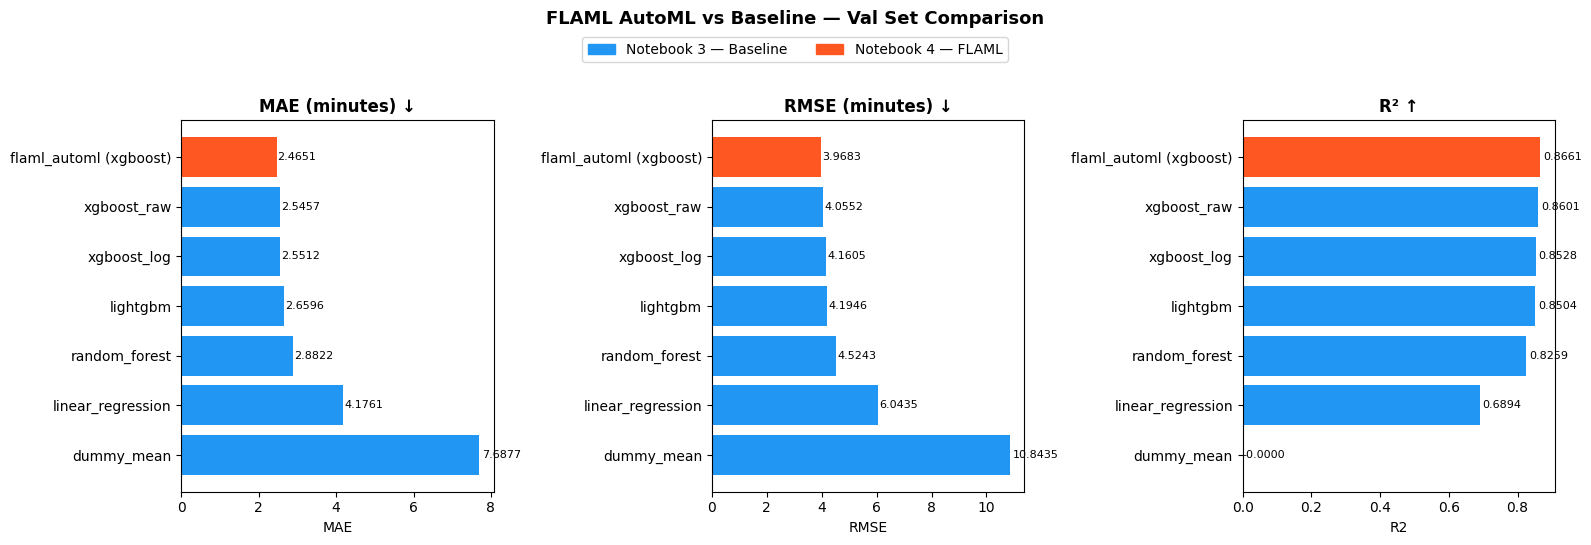

Plot saved to reports/flaml_vs_baseline.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['mae', 'rmse', 'r2']
titles  = ['MAE (minutes) ↓', 'RMSE (minutes) ↓', 'R² ↑']
palette = ['#2196F3' if s == 'Notebook 3' else '#FF5722' for s in cmp_df['source']]

for ax, metric, title in zip(axes, metrics, titles):
    order = cmp_df.sort_values(metric, ascending=(metric != 'r2'))
    colors = ['#2196F3' if s == 'Notebook 3' else '#FF5722' for s in order['source']]
    bars = ax.barh(order['model'], order[metric], color=colors)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(metric.upper())
    for bar, val in zip(bars, order[metric]):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)
    ax.invert_yaxis()

from matplotlib.patches import Patch
legend = [Patch(color='#2196F3', label='Notebook 3 — Baseline'),
          Patch(color='#FF5722', label='Notebook 4 — FLAML')]
fig.legend(handles=legend, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.04))

plt.suptitle('FLAML AutoML vs Baseline — Val Set Comparison', fontsize=13, fontweight='bold', y=1.08)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'flaml_vs_baseline.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot saved to reports/flaml_vs_baseline.png')

---
## Section 8 — Save FLAML Model if it Beats Baseline

In [12]:
if flaml_val_metrics['mae'] < BASELINE_VAL_MAE:
    print(f'FLAML ({flaml_val_metrics["mae"]:.4f}) beats baseline ({BASELINE_VAL_MAE:.4f}) — saving...')

    with open(MODEL_SAVE_PATH, 'wb') as f:
        pickle.dump(automl.model.estimator, f)

    updated_meta = baseline_meta.copy()
    updated_meta['model_name']   = f'flaml_{automl.best_estimator}'
    updated_meta['log_transform'] = False
    updated_meta['features']     = available_features
    updated_meta['val_metrics']  = {k: round(float(v), 4) for k, v in flaml_val_metrics.items()}
    updated_meta['test_metrics'] = {k: round(float(v), 4) for k, v in flaml_test_metrics.items()}
    updated_meta['hyperparams']  = automl.best_config

    with open(METADATA_SAVE_PATH, 'w') as f:
        json.dump(updated_meta, f, indent=2)

    print(f'Model saved   : {MODEL_SAVE_PATH}')
    print(f'Metadata saved: {METADATA_SAVE_PATH}')
else:
    print(f'Baseline ({BASELINE_VAL_MAE:.4f}) still wins — best_model.pkl unchanged.')
    print(f'FLAML val MAE: {flaml_val_metrics["mae"]:.4f}')

FLAML (2.4651) beats baseline (2.5457) — saving...
Model saved   : /Users/adityaboghara/Desktop/NYC End to End Project /nyc-taxi-duration-prediction-self-healing-ml/models/best_model.pkl
Metadata saved: /Users/adityaboghara/Desktop/NYC End to End Project /nyc-taxi-duration-prediction-self-healing-ml/models/model_metadata.json


---
## Summary

| Item | Detail |
|---|---|
| FLAML budget | `FLAML_TIME_BUDGET` seconds |
| Models searched | XGBoost, LightGBM, Random Forest |
| Val set | Time-based — Jan 18–24 (identical to Notebook 3) |
| MLflow run | `flaml_automl` in `nyc-taxi-duration` experiment |
| Plot | `reports/flaml_vs_baseline.png` |

### Next
- **Notebook 5** — Hyperparameter tuning with Optuna on the current best model
- **Notebook 6** — SHAP explainability
- **Notebook 7** — Drift simulation & monitoring baseline (Evidently)